In [15]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    "data/OMXS22_raw_features.csv",
    parse_dates=["Date"],
    index_col="Date"
)
start_test_point = df.index[-200*22]
print(start_test_point)
all_tickers = df['Ticker'].unique()
print(all_tickers)


feature_cols = ["Close","Volume",
                "MarketCap","Weight",
                "Return","LogReturn","WeightedRet",
                "SMA20","EMA20","RSI14","ReturnVola20"]

chosen_ticker = "KINV-B.ST"

import numpy, torch, scipy
print("NumPy :", numpy.__version__)   # → 1.26.4
print("Torch :", torch.__version__)   # → 2.2.2
print("SciPy :", scipy.__version__)   # → 1.15.2

2024-07-11 00:00:00
['ASSA-B.ST' 'ATCO-A.ST' 'ATCO-B.ST' 'AZN.ST' 'ELUX-B.ST' 'ERIC-B.ST'
 'GETI-B.ST' 'HEXA-B.ST' 'HM-B.ST' 'INVE-B.ST' 'KINV-B.ST' 'NDA-SE.ST'
 'NIBE-B.ST' 'SAAB-B.ST' 'SAND.ST' 'SCA-B.ST' 'SEB-A.ST' 'SHB-A.ST'
 'SKF-B.ST' 'SWED-A.ST' 'TEL2-B.ST' 'VOLV-B.ST']
NumPy : 1.26.4
Torch : 2.2.2
SciPy : 1.15.2


In [16]:

window_step_length = 6
window_size = 50
num_test_points = 200

horizon = 4 #3 is good
target_idx = 0



Shape dataset (6409, 11)
means:  Close           1.043935e+02
Volume          4.174720e+06
MarketCap       1.099524e+11
Weight          3.379463e-02
Return          5.710548e-04
LogReturn       3.715475e-04
WeightedRet     2.191627e-05
SMA20           1.040219e+02
EMA20           1.040130e+02
RSI14           5.227815e+01
ReturnVola20    1.814528e-02
dtype: float64
stds:  Close           8.875950e+01
Volume          4.600011e+06
MarketCap       9.348594e+10
Weight          1.282733e-02
Return          2.000137e-02
LogReturn       1.996333e-02
WeightedRet     6.095575e-04
SMA20           8.849015e+01
EMA20           8.844715e+01
RSI14           1.056618e+01
ReturnVola20    8.856161e-03
dtype: float64


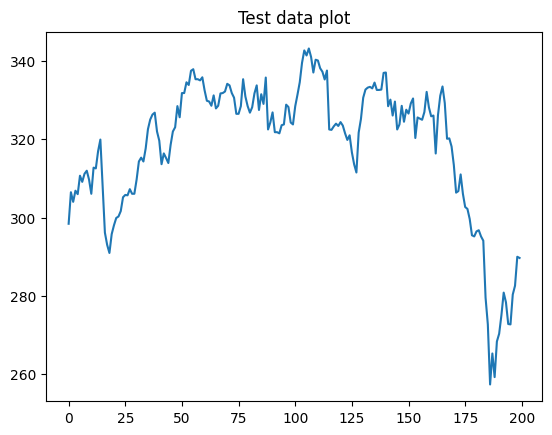

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.229195827019973
Normalized Benchmark: 0.027963861450319517


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

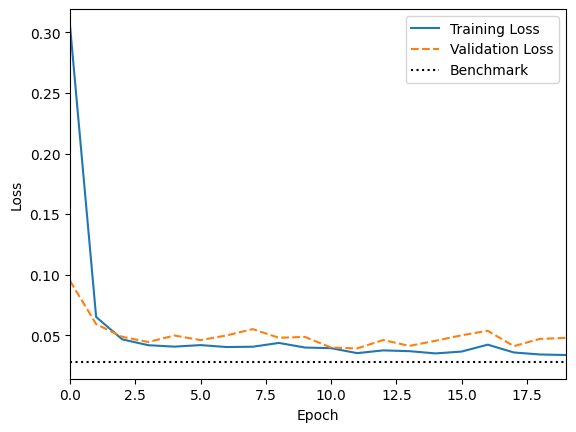

variance of returns for old data:  0.0013926405058056286
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(292.0483)
windows last2 price:  tensor(290.4776)
windows last3 price:  tensor(295.1897)
period from idx:  0  to idx  4
prediction at 4:  tensor(282.7696)
last price from test data:  292.0483093261719
real price 4 steps forward:  tensor(305.9881)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(305.9881)
windows last2 price:  tensor(306.8716)
windows last3 price:  tensor(304.0247)
period from idx:  4  to idx  8
prediction at 4:  tensor(296.6520)
last price from test data:  tensor(305.9881)
real price 4 steps forward:  tensor(311.9763)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(311.9763)
windows last2 price:  tensor(311.1910)
windows last3 price:  

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


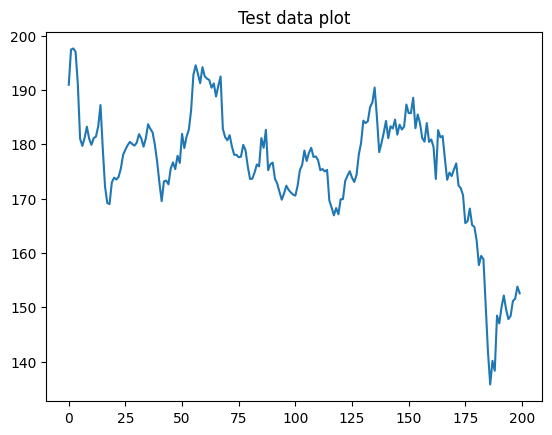

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.9998097162684735
Normalized Benchmark: 0.022320624340748458


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

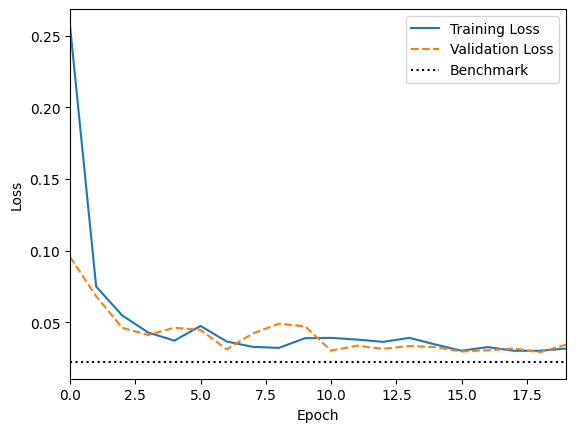

variance of returns for old data:  0.001606909463452383
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(189.3760)
windows last2 price:  tensor(189.9653)
windows last3 price:  tensor(192.6665)
period from idx:  0  to idx  4
prediction at 4:  tensor(192.9204)
last price from test data:  189.37600708007807
real price 4 steps forward:  tensor(191.0458)
kelly weight:  {tensor(11.6473, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(191.0458)
windows last2 price:  tensor(197.0375)
windows last3 price:  tensor(197.6268)
period from idx:  4  to idx  8
prediction at 4:  tensor(196.1094)
last price from test data:  tensor(191.0458)
real price 4 steps forward:  tensor(183.2370)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(183.2370)
windows last2 price:  tensor(181.1743)
windows last3 price:

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


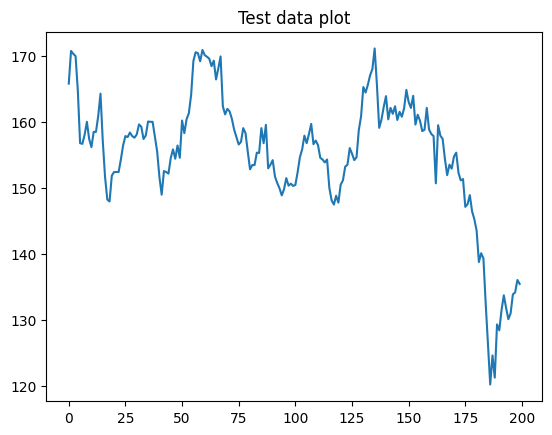

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.8775575074911309
Normalized Benchmark: 0.023025542851137705


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

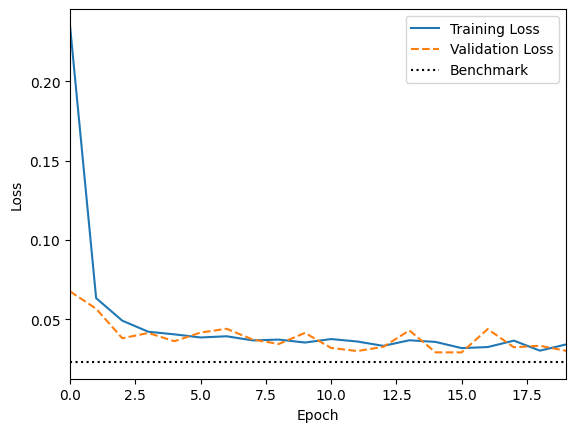

variance of returns for old data:  0.0017023516815117402
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(164.0397)
windows last2 price:  tensor(163.2556)
windows last3 price:  tensor(165.4120)
period from idx:  0  to idx  4
prediction at 4:  tensor(162.3656)
last price from test data:  164.0397491455078
real price 4 steps forward:  tensor(164.6769)
kelly weight:  {tensor(-5.9952, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(164.6769)
windows last2 price:  tensor(169.9211)
windows last3 price:  tensor(170.2641)
period from idx:  4  to idx  8
prediction at 4:  tensor(165.4873)
last price from test data:  tensor(164.6769)
real price 4 steps forward:  tensor(159.9718)
kelly weight:  {tensor(2.8909, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(159.9718)
windows last2 price:  tensor(158.0114)
windows last3 pri

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


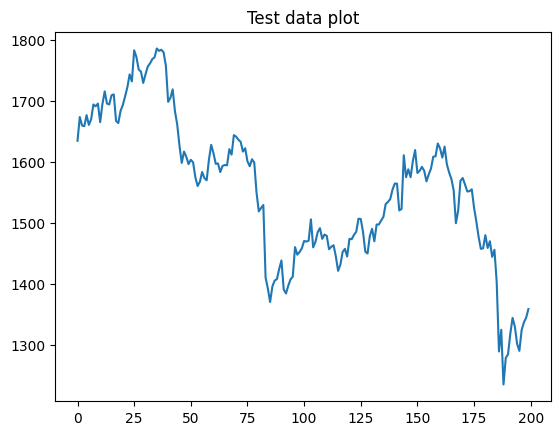

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 11.767553907666448
Normalized Benchmark: 0.0338749758241002


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

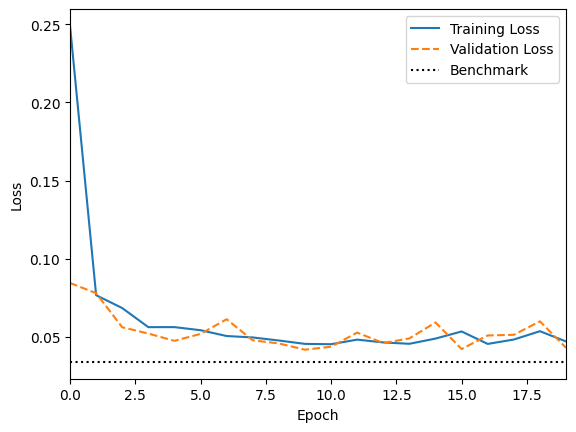

variance of returns for old data:  0.0009891226761606295
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1633.0167)
windows last2 price:  tensor(1613.5463)
windows last3 price:  tensor(1626.0273)
period from idx:  0  to idx  4
prediction at 4:  tensor(1628.0311)
last price from test data:  1633.0167236328125
real price 4 steps forward:  tensor(1676.4507)
kelly weight:  {tensor(-3.0866, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1676.4507)
windows last2 price:  tensor(1658.4780)
windows last3 price:  tensor(1659.4764)
period from idx:  4  to idx  8
prediction at 4:  tensor(1658.4370)
last price from test data:  tensor(1676.4507)
real price 4 steps forward:  tensor(1690.9286)
kelly weight:  {tensor(-10.8633, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(1690.9286)
windows last2 price:  tensor(1693.9241)
w

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


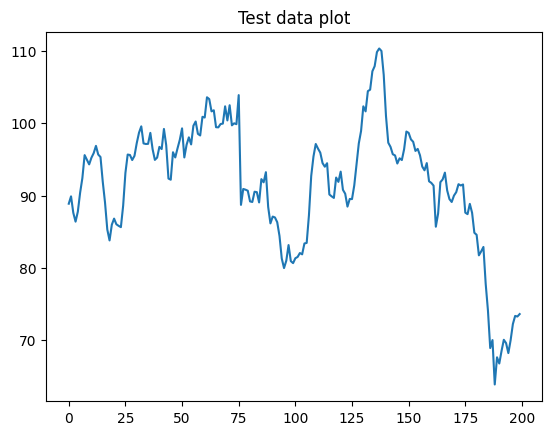

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.487879212876657
Normalized Benchmark: 0.04822933069118759


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

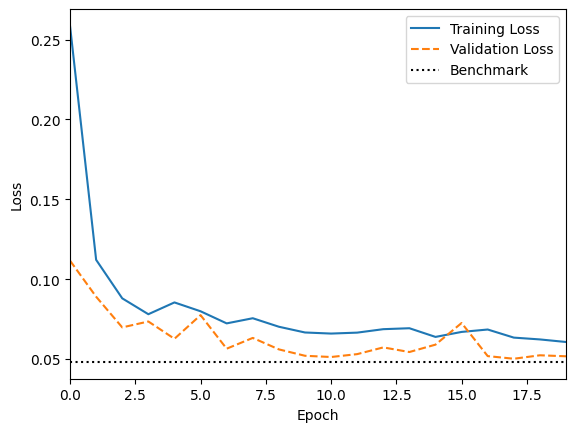

variance of returns for old data:  0.0019440529062390445
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(85.6200)
windows last2 price:  tensor(86.)
windows last3 price:  tensor(86.8200)
period from idx:  0  to idx  4
prediction at 4:  tensor(88.0182)
last price from test data:  85.62000274658203
real price 4 steps forward:  tensor(87.7800)
kelly weight:  {tensor(14.4081, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(87.7800)
windows last2 price:  tensor(86.4000)
windows last3 price:  tensor(87.6200)
period from idx:  4  to idx  8
prediction at 4:  tensor(87.2459)
last price from test data:  tensor(87.7800)
real price 4 steps forward:  tensor(94.9600)
kelly weight:  {tensor(-3.1300, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(94.9600)
windows last2 price:  tensor(95.6000)
windows last3 price:  tensor(92.4

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


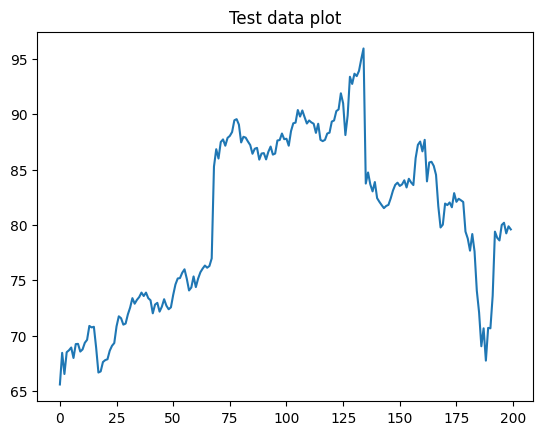

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.766200875121677
Normalized Benchmark: 0.04875824096586497


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

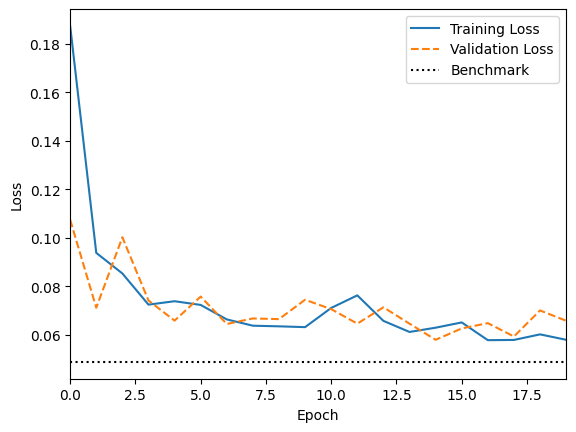

variance of returns for old data:  0.0029237230637904022
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(65.6036)
windows last2 price:  tensor(65.0822)
windows last3 price:  tensor(65.5650)
period from idx:  0  to idx  4
prediction at 4:  tensor(64.3952)
last price from test data:  65.60363006591797
real price 4 steps forward:  tensor(68.6743)
kelly weight:  {tensor(-6.3004, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(68.6743)
windows last2 price:  tensor(68.5005)
windows last3 price:  tensor(66.5306)
period from idx:  4  to idx  8
prediction at 4:  tensor(67.0374)
last price from test data:  tensor(68.6743)
real price 4 steps forward:  tensor(69.2536)
kelly weight:  {tensor(-8.1524, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(69.2536)
windows last2 price:  tensor(69.2343)
windows last3 price:  tensor(

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


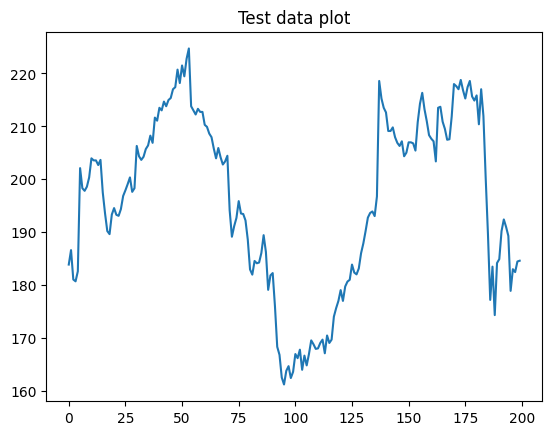

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.8848611790167524
Normalized Benchmark: 0.03867404426456551


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

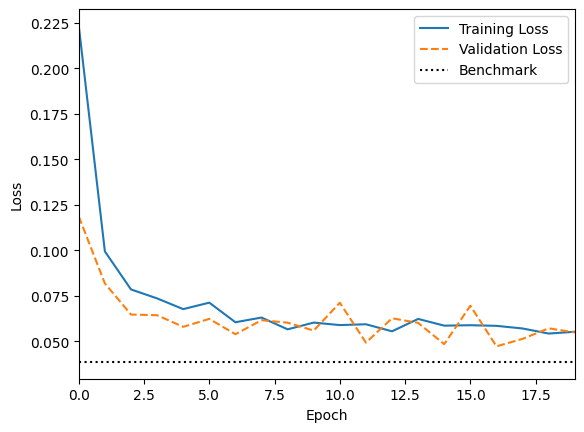

variance of returns for old data:  0.0015566765914555188
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(179.4850)
windows last2 price:  tensor(177.1939)
windows last3 price:  tensor(180.8499)
period from idx:  0  to idx  4
prediction at 4:  tensor(184.6741)
last price from test data:  179.48497009277344
real price 4 steps forward:  tensor(182.6048)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(182.6048)
windows last2 price:  tensor(180.7036)
windows last3 price:  tensor(181.0449)
period from idx:  4  to idx  8
prediction at 4:  tensor(184.9144)
last price from test data:  tensor(182.6048)
real price 4 steps forward:  tensor(198.5936)
kelly weight:  {tensor(8.1253, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(198.5936)
windows last2 price:  tensor(197.8137)
windows last3 price:

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


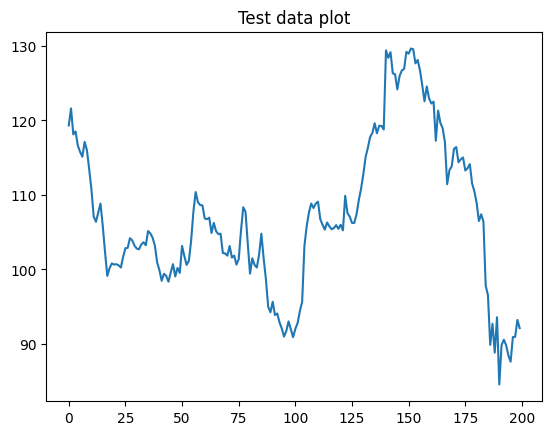

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.0065827991384158
Normalized Benchmark: 0.025912110356124146


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

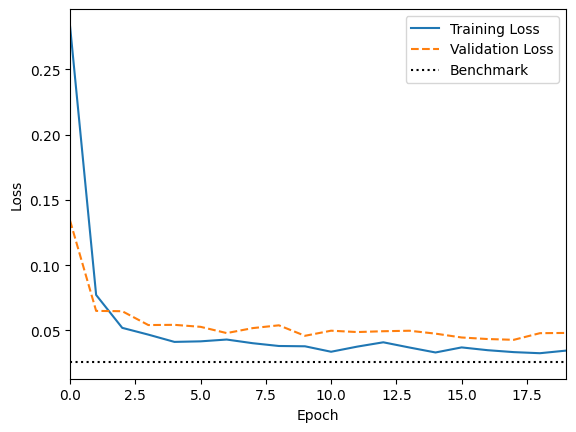

variance of returns for old data:  0.0018980036865123098
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(117.2752)
windows last2 price:  tensor(117.2253)
windows last3 price:  tensor(121.1195)
period from idx:  0  to idx  4
prediction at 4:  tensor(121.6281)
last price from test data:  117.27518463134766
real price 4 steps forward:  tensor(116.6262)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(116.6262)
windows last2 price:  tensor(118.5233)
windows last3 price:  tensor(118.1239)
period from idx:  4  to idx  8
prediction at 4:  tensor(120.3194)
last price from test data:  tensor(116.6262)
real price 4 steps forward:  tensor(116.0270)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(116.0270)
windows last2 price:  tensor(117.1254)
windows last3 price:  t

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           1.124769e+02
Volume          4.486822e+06
MarketCap       1.586026e+11
Weight          6.663908e-02
Return          3.326230e-04
LogReturn       1.322083e-04
WeightedRet     3.252568e-05
SMA20           1.123751e+02
EMA20           1.123738e+02
RSI14           5.114224e+01
ReturnVola20    1.792313e-02
dtype: float64
stds:  Close           5.126364e+01
Volume          3.703587e+06
MarketCap       7.228634e+10
Weight          2.906663e-02
Return          2.000668e-02
LogReturn       2.004285e-02
WeightedRet     1.231014e-03
SMA20           5.114403e+01
EMA20           5.108067e+01
RSI14           1.187563e+01
ReturnVola20    9.193808e-03
dtype: float64


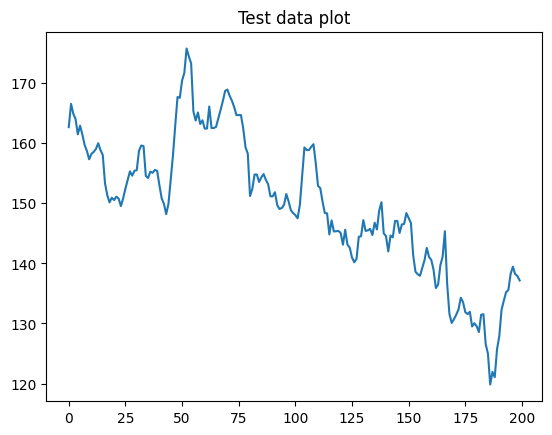

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.8500536811822466
Normalized Benchmark: 0.054867441605830694


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

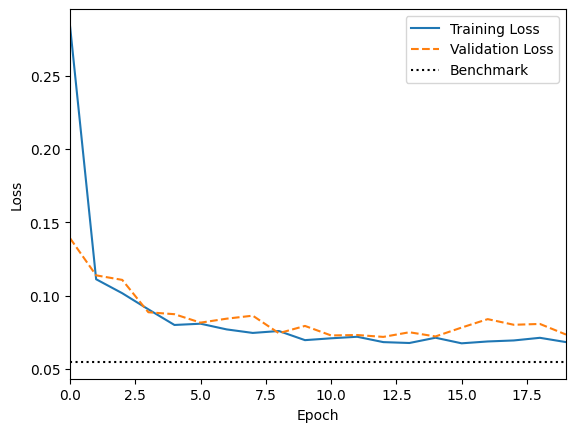

variance of returns for old data:  0.0015491160426207105
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(162.1386)
windows last2 price:  tensor(161.2309)
windows last3 price:  tensor(163.2851)
period from idx:  0  to idx  4
prediction at 4:  tensor(153.9356)
last price from test data:  162.1385955810547
real price 4 steps forward:  tensor(161.4698)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(161.4698)
windows last2 price:  tensor(164.0017)
windows last3 price:  tensor(164.9094)
period from idx:  4  to idx  8
prediction at 4:  tensor(154.6040)
last price from test data:  tensor(161.4698)
real price 4 steps forward:  tensor(158.6990)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(158.6990)
windows last2 price:  tensor(159.7022)
windows last3 price:  

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           6.852715e+01
Volume          6.156325e+06
MarketCap       1.244638e+11
Weight          3.463388e-02
Return          5.886146e-04
LogReturn       4.593421e-04
WeightedRet     2.384091e-05
SMA20           6.814239e+01
EMA20           6.813367e+01
RSI14           5.373107e+01
ReturnVola20    1.455681e-02
dtype: float64
stds:  Close           7.483567e+01
Volume          5.148563e+06
MarketCap       1.359218e+11
Weight          1.616433e-02
Return          1.608002e-02
LogReturn       1.607166e-02
WeightedRet     5.481227e-04
SMA20           7.440418e+01
EMA20           7.436290e+01
RSI14           1.192278e+01
ReturnVola20    6.974782e-03
dtype: float64


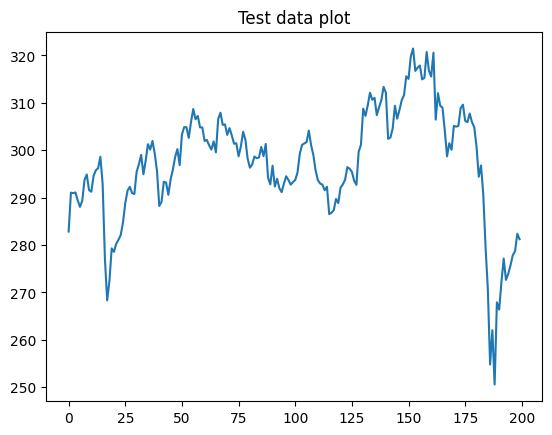

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.2283572972349157
Normalized Benchmark: 0.019749477305913674


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

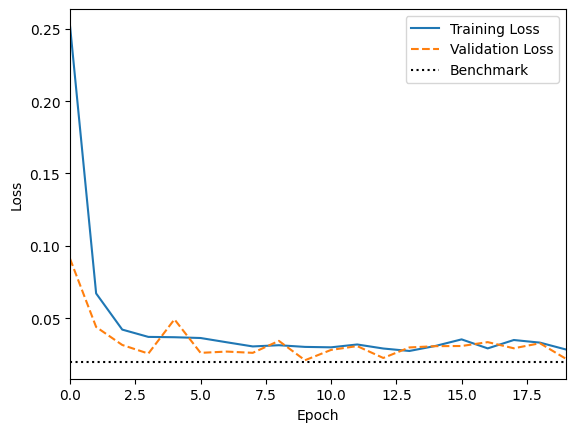

variance of returns for old data:  0.0009956620179480547
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(282.0987)
windows last2 price:  tensor(282.0496)
windows last3 price:  tensor(283.1799)
period from idx:  0  to idx  4
prediction at 4:  tensor(287.9505)
last price from test data:  282.0987243652344
real price 4 steps forward:  tensor(289.4215)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(289.4215)
windows last2 price:  tensor(291.0925)
windows last3 price:  tensor(290.9450)
period from idx:  4  to idx  8
prediction at 4:  tensor(293.8420)
last price from test data:  tensor(289.4215)
real price 4 steps forward:  tensor(294.8767)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(294.8767)
windows last2 price:  tensor(293.6972)
windows last3 price:  te

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


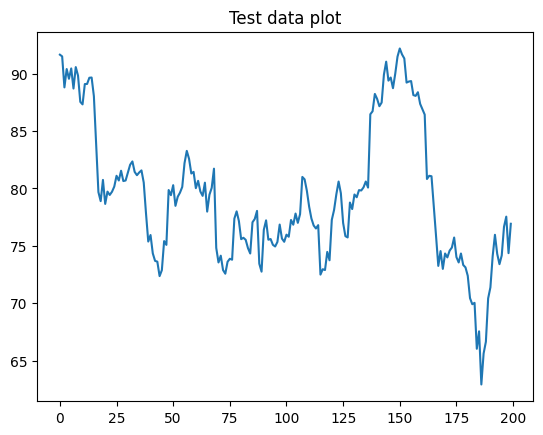

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.5449491995750755
Normalized Benchmark: 0.03460170547106683


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

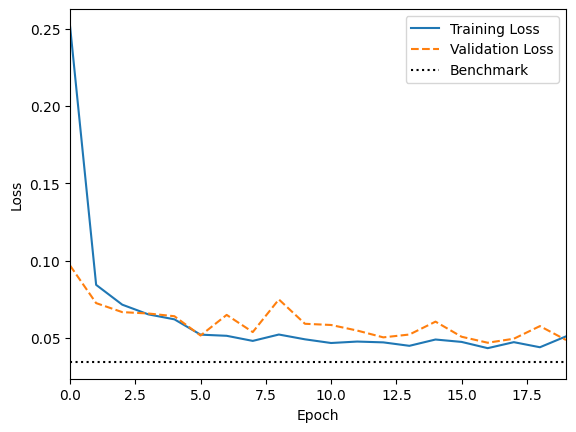

variance of returns for old data:  0.0021719292793457817
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(89.5000)
windows last2 price:  tensor(91.2000)
windows last3 price:  tensor(86.9000)
period from idx:  0  to idx  4
prediction at 4:  tensor(99.3443)
last price from test data:  89.5
real price 4 steps forward:  tensor(89.5500)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(89.5500)
windows last2 price:  tensor(90.4000)
windows last3 price:  tensor(88.8000)
period from idx:  4  to idx  8
prediction at 4:  tensor(97.5580)
last price from test data:  tensor(89.5500)
real price 4 steps forward:  tensor(89.8300)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(89.8300)
windows last2 price:  tensor(90.5700)
windows last3 price:  tensor(88.7000)
period from 

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           6.917273e+01
Volume          9.930917e+06
MarketCap       2.396655e+11
Weight          9.951619e-02
Return          4.249452e-04
LogReturn       2.329807e-04
WeightedRet     4.869774e-05
SMA20           6.903185e+01
EMA20           6.902893e+01
RSI14           5.202671e+01
ReturnVola20    1.732612e-02
dtype: float64
stds:  Close           2.725729e+01
Volume          7.372963e+06
MarketCap       9.443943e+10
Weight          2.920079e-02
Return          1.962439e-02
LogReturn       1.958325e-02
WeightedRet     2.109760e-03
SMA20           2.713884e+01
EMA20           2.709955e+01
RSI14           1.127319e+01
ReturnVola20    9.461042e-03
dtype: float64


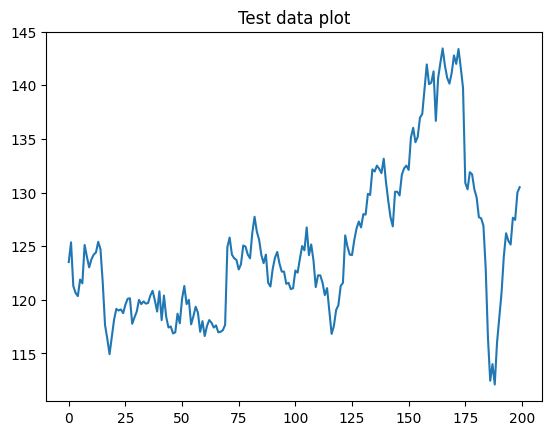

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.6353150465332817
Normalized Benchmark: 0.06411810005899392


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

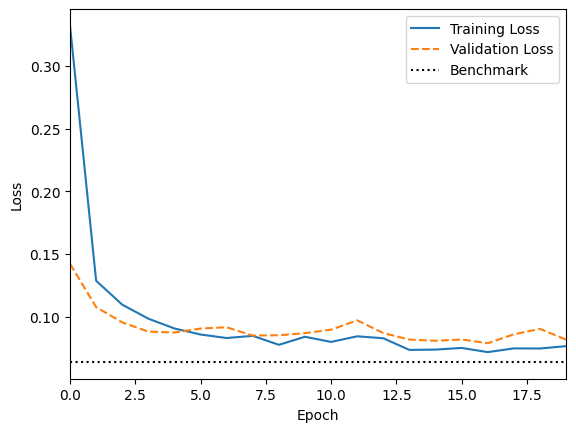

variance of returns for old data:  0.0014133088403189397
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.5259)
windows last2 price:  tensor(121.7809)
windows last3 price:  tensor(124.7112)
period from idx:  0  to idx  4
prediction at 4:  tensor(123.3958)
last price from test data:  122.52590942382812
real price 4 steps forward:  tensor(120.3406)
kelly weight:  {tensor(5.0232, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(120.3406)
windows last2 price:  tensor(120.6386)
windows last3 price:  tensor(121.2843)
period from idx:  4  to idx  8
prediction at 4:  tensor(122.1769)
last price from test data:  tensor(120.3406)
real price 4 steps forward:  tensor(124.0159)
kelly weight:  {tensor(10.7966, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(124.0159)
windows last2 price:  tensor(125.1085)
windows last3 pr

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(130.3000)
windows last2 price:  tensor(130.9000)
windows last3 price:  tensor(139.7600)
period from idx:  176  to idx  180
prediction at 4:  tensor(131.6459)
last price from test data:  tensor(130.3000)
real price 4 steps forward:  tensor(129.5500)
kelly weight:  {tensor(7.3086, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(129.5500)
windows last2 price:  tensor(130.3000)
windows last3 price:  tensor(131.7000)
period from idx:  180  to idx  184
prediction at 4:  tensor(131.9821)
last price from test data:  tensor(129.5500)
real price 4 steps forward:  tensor(122.9500)
kelly weight:  {tensor(13.2835, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(122.9500)
windows last2 price:  tensor(126.9000)
windows last3 price:  tensor(127.6000)
period from idx:  184  to idx  188
prediction at 4:  tensor(127.1573)
last price from test data:  tensor(122

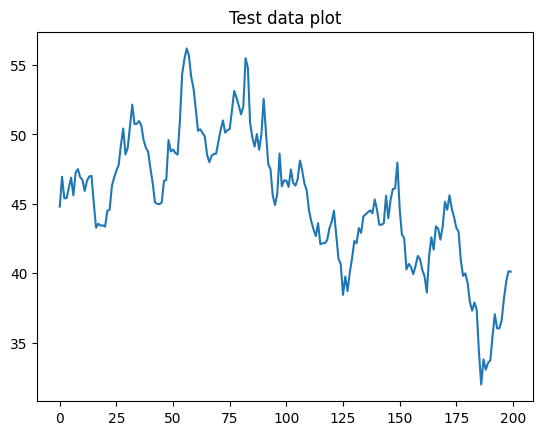

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.7269589763606008
Normalized Benchmark: 0.023301131264559714


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

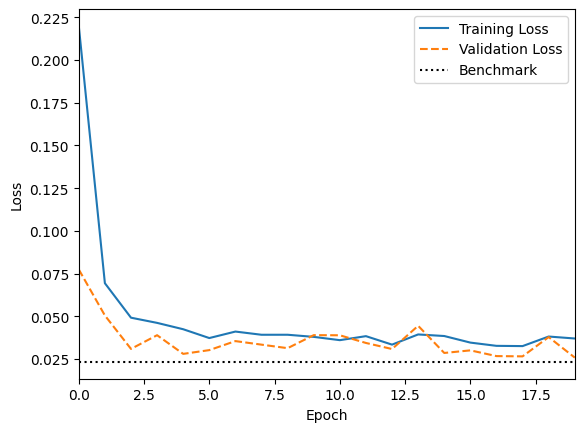

variance of returns for old data:  0.0017200828710812772
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(43.3000)
windows last2 price:  tensor(44.7200)
windows last3 price:  tensor(46.5200)
period from idx:  0  to idx  4
prediction at 4:  tensor(46.2007)
last price from test data:  43.29999923706055
real price 4 steps forward:  tensor(46.1600)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(46.1600)
windows last2 price:  tensor(45.4100)
windows last3 price:  tensor(45.4000)
period from idx:  4  to idx  8
prediction at 4:  tensor(46.3373)
last price from test data:  tensor(46.1600)
real price 4 steps forward:  tensor(47.5000)
kelly weight:  {tensor(2.2336, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(47.5000)
windows last2 price:  tensor(47.2400)
windows last3 price:  tensor(45.61

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


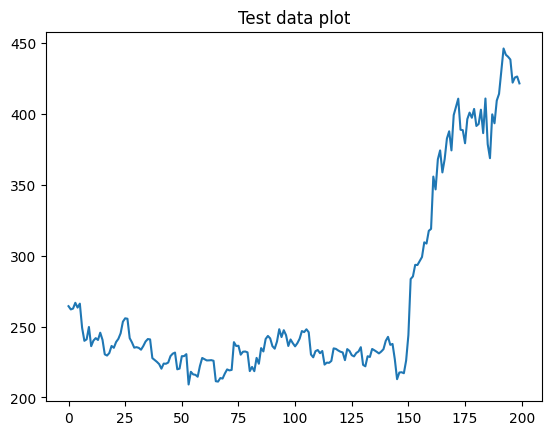

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.2754211285919264
Normalized Benchmark: 0.03330915140247957


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

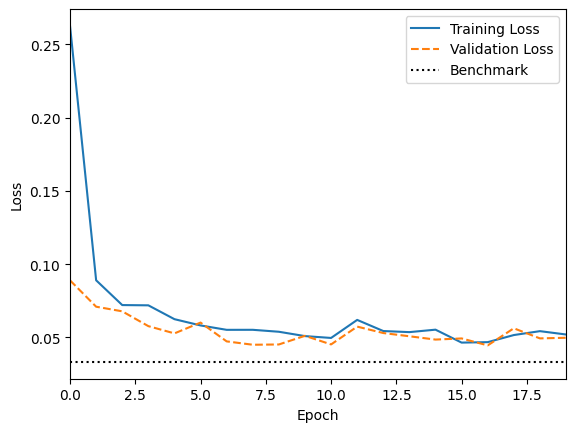

variance of returns for old data:  0.0016658513021971094
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(264.1200)
windows last2 price:  tensor(255.4718)
windows last3 price:  tensor(255.2729)
period from idx:  0  to idx  4
prediction at 4:  tensor(254.6680)
last price from test data:  264.1200256347656
real price 4 steps forward:  tensor(263.3247)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(263.3247)
windows last2 price:  tensor(266.7045)
windows last3 price:  tensor(262.6289)
period from idx:  4  to idx  8
prediction at 4:  tensor(261.0692)
last price from test data:  tensor(263.3247)
real price 4 steps forward:  tensor(240.9586)
kelly weight:  {tensor(-5.1418, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(240.9586)
windows last2 price:  tensor(239.9148)
windows last3 price

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           8.497358e+01
Volume          1.299748e+07
MarketCap       1.065900e+11
Weight          3.698159e-02
Return          5.509936e-04
LogReturn       3.451081e-04
WeightedRet     2.435851e-05
SMA20           8.473066e+01
EMA20           8.472163e+01
RSI14           5.198045e+01
ReturnVola20    1.871712e-02
dtype: float64
stds:  Close           6.016947e+01
Volume          1.769806e+07
MarketCap       7.547598e+10
Weight          1.018234e-02
Return          2.030475e-02
LogReturn       2.028625e-02
WeightedRet     7.855251e-04
SMA20           5.999684e+01
EMA20           5.994200e+01
RSI14           1.116290e+01
ReturnVola20    8.165567e-03
dtype: float64


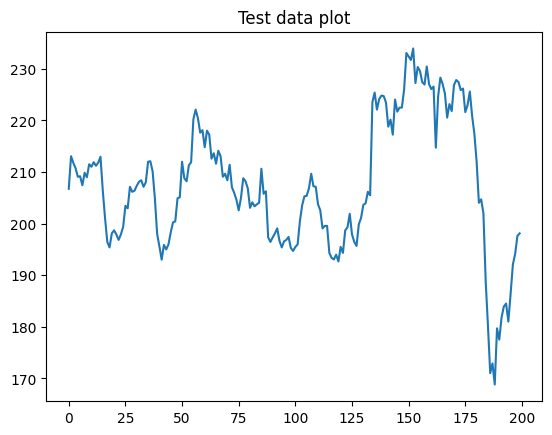

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.247645860252411
Normalized Benchmark: 0.03946230865154385


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

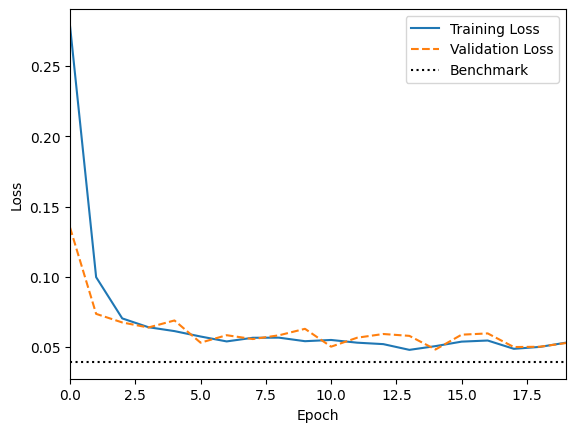

variance of returns for old data:  0.0015642780056088369
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(204.5199)
windows last2 price:  tensor(203.7426)
windows last3 price:  tensor(207.4347)
period from idx:  0  to idx  4
prediction at 4:  tensor(213.8189)
last price from test data:  204.5198974609375
real price 4 steps forward:  tensor(209.0864)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(209.0864)
windows last2 price:  tensor(210.7381)
windows last3 price:  tensor(211.8068)
period from idx:  4  to idx  8
prediction at 4:  tensor(216.2920)
last price from test data:  tensor(209.0864)
real price 4 steps forward:  tensor(208.9892)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(208.9892)
windows last2 price:  tensor(209.8636)
windows last3 price:  te

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(222.9801)
windows last2 price:  tensor(221.6199)
windows last3 price:  tensor(226.1864)
period from idx:  176  to idx  180
prediction at 4:  tensor(222.1609)
last price from test data:  tensor(222.9801)
real price 4 steps forward:  tensor(212.0011)
kelly weight:  {tensor(-2.3485, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(212.0011)
windows last2 price:  tensor(217.4420)
windows last3 price:  tensor(220.9398)
period from idx:  180  to idx  184
prediction at 4:  tensor(217.4048)
last price from test data:  tensor(212.0011)
real price 4 steps forward:  tensor(188.8287)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(188.8287)
windows last2 price:  tensor(201.9937)
windows last3 price:  tensor(204.7142)
period from idx:  184  to idx  188
prediction at 4:  tensor(208.3706)
last price from test data:  tensor(188.82

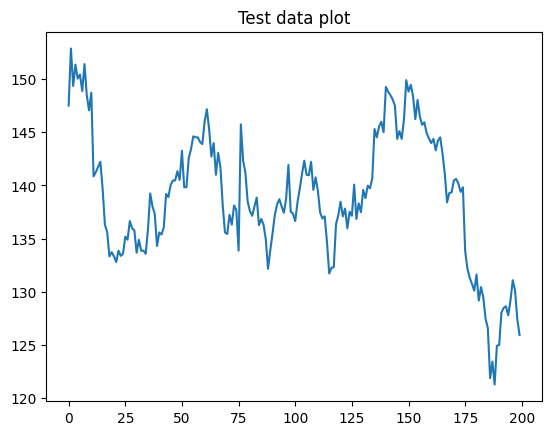

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 0.9609792621456549
Normalized Benchmark: 0.01880180324312972


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

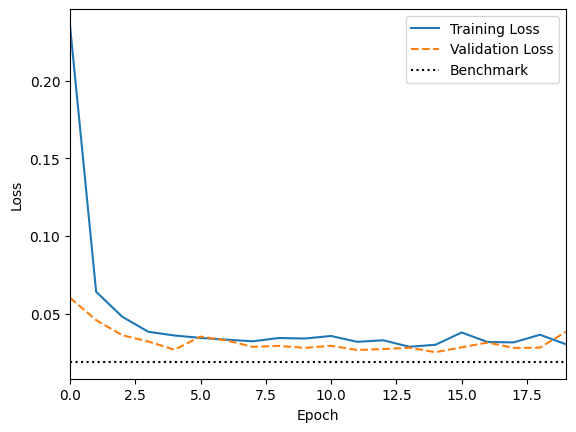

variance of returns for old data:  0.001376396430050637
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(149.4583)
windows last2 price:  tensor(148.9211)
windows last3 price:  tensor(148.7257)
period from idx:  0  to idx  4
prediction at 4:  tensor(145.0122)
last price from test data:  149.45834350585938
real price 4 steps forward:  tensor(150.0444)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(150.0444)
windows last2 price:  tensor(151.3632)
windows last3 price:  tensor(149.3606)
period from idx:  4  to idx  8
prediction at 4:  tensor(147.4103)
last price from test data:  tensor(150.0444)
real price 4 steps forward:  tensor(148.4815)
kelly weight:  {tensor(-12.7550, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(148.4815)
windows last2 price:  tensor(151.4120)
windows last3 pric

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


Shape dataset (6409, 11)
means:  Close           5.169699e+01
Volume          6.382440e+06
MarketCap       1.009715e+11
Weight          3.619967e-02
Return          6.064208e-04
LogReturn       3.659038e-04
WeightedRet     2.336729e-05
SMA20           5.150549e+01
EMA20           5.149921e+01
RSI14           5.290098e+01
ReturnVola20    1.844762e-02
dtype: float64
stds:  Close           3.515278e+01
Volume          4.300964e+06
MarketCap       6.865831e+10
Weight          8.730028e-03
Return          2.196654e-02
LogReturn       2.192424e-02
WeightedRet     7.451641e-04
SMA20           3.495493e+01
EMA20           3.492003e+01
RSI14           1.126631e+01
ReturnVola20    1.217613e-02
dtype: float64


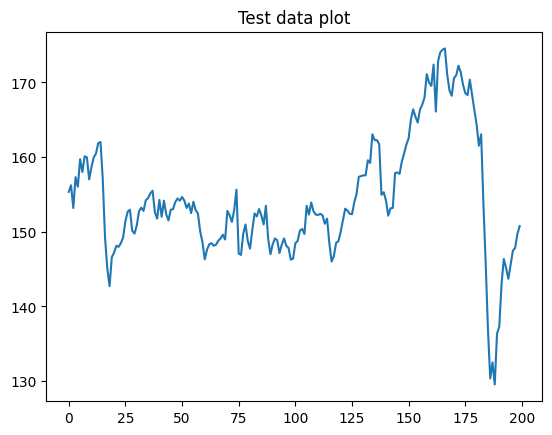

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.162688205974127
Normalized Benchmark: 0.040190461220862804


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

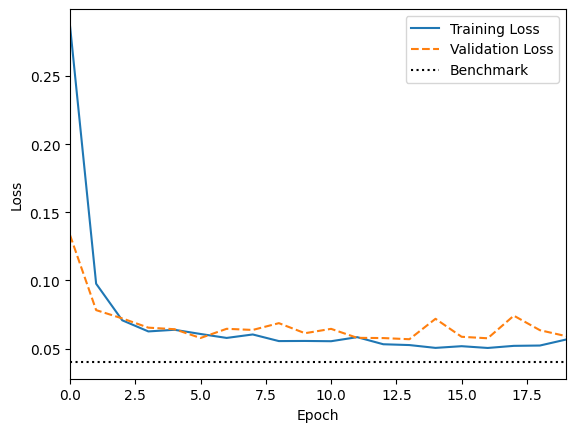

variance of returns for old data:  0.0018625048191737085
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(151.2177)
windows last2 price:  tensor(150.2849)
windows last3 price:  tensor(151.6596)
period from idx:  0  to idx  4
prediction at 4:  tensor(152.2049)
last price from test data:  151.21771240234375
real price 4 steps forward:  tensor(156.0292)
kelly weight:  {tensor(3.5050, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(156.0292)
windows last2 price:  tensor(157.3057)
windows last3 price:  tensor(153.1816)
period from idx:  4  to idx  8
prediction at 4:  tensor(156.3148)
last price from test data:  tensor(156.0292)
real price 4 steps forward:  tensor(159.9569)
kelly weight:  {tensor(0.9829, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(159.9569)
windows last2 price:  tensor(160.1042)
windows last3 pri

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(146.3500)
windows last2 price:  tensor(143.)
windows last3 price:  tensor(137.3000)
period from idx:  192  to idx  196
prediction at 4:  tensor(159.8612)
last price from test data:  tensor(146.3500)
real price 4 steps forward:  tensor(147.4500)
kelly weight:  {tensor(15., dtype=torch.float64)}
 
Shape dataset (6409, 11)
means:  Close           4.976801e+01
Volume          6.029860e+06
MarketCap       9.678784e+10
Weight          3.640911e-02
Return          4.999781e-04
LogReturn       3.524686e-04
WeightedRet     1.946456e-05
SMA20           4.962028e+01
EMA20           4.961762e+01
RSI14           5.213850e+01
ReturnVola20    1.526763e-02
dtype: float64
stds:  Close           2.728260e+01
Volume          4.042293e+06
MarketCap       5.305865e+10
Weight          9.438885e-03
Return          1.718571e-02
LogReturn       1.717009e-02
WeightedRet     6.196107e-04
SMA20           2.717337e+01
EMA20           2.715121e+01
RSI

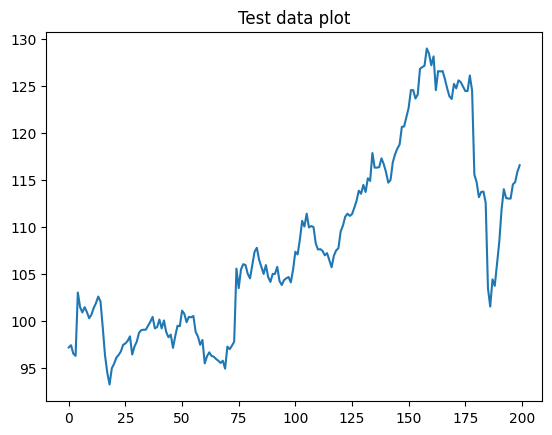

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.0567993509875104
Normalized Benchmark: 0.0415882687526447


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

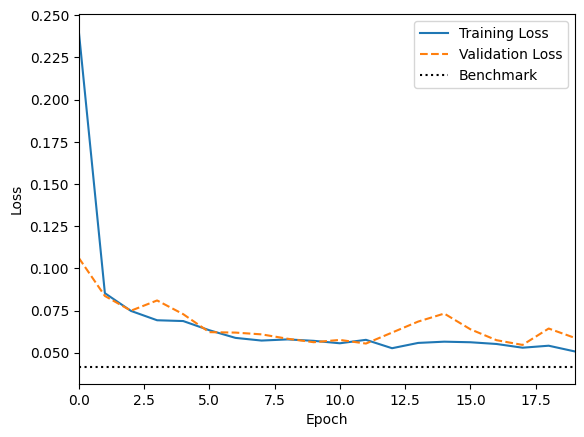

variance of returns for old data:  0.0010557027843749087
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(95.8744)
windows last2 price:  tensor(94.3182)
windows last3 price:  tensor(95.2142)
period from idx:  0  to idx  4
prediction at 4:  tensor(94.3418)
last price from test data:  95.87443542480467
real price 4 steps forward:  tensor(102.9955)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(102.9955)
windows last2 price:  tensor(96.2517)
windows last3 price:  tensor(96.4875)
period from idx:  4  to idx  8
prediction at 4:  tensor(97.5742)
last price from test data:  tensor(102.9955)
real price 4 steps forward:  tensor(100.9205)
kelly weight:  {tensor(-15., dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.9205)
windows last2 price:  tensor(101.4392)
windows last3 price:  tensor(

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


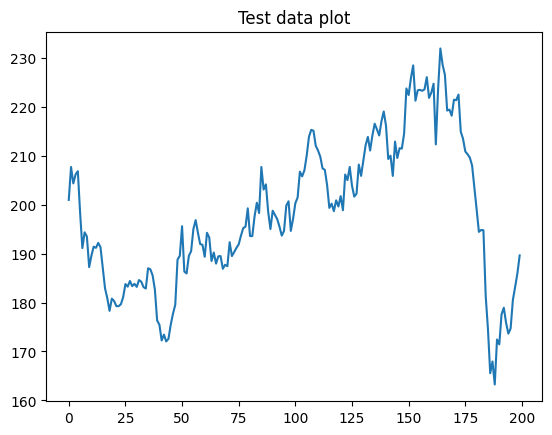

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 2.6281583283429755
Normalized Benchmark: 0.05093187519368235


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

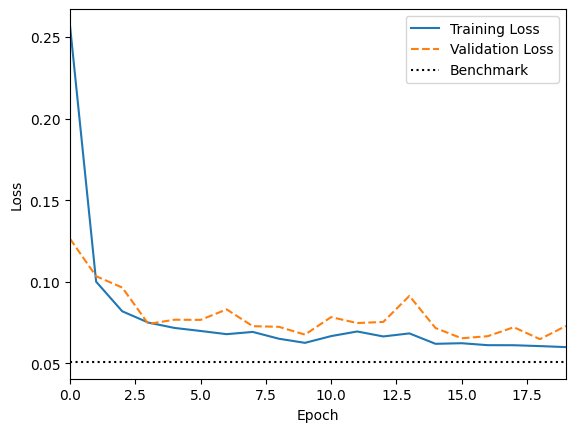

variance of returns for old data:  0.0015153797149533254
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(198.6008)
windows last2 price:  tensor(198.4085)
windows last3 price:  tensor(204.7560)
period from idx:  0  to idx  4
prediction at 4:  tensor(202.8873)
last price from test data:  198.60081481933597
real price 4 steps forward:  tensor(206.8718)
kelly weight:  {tensor(14.2428, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(206.8718)
windows last2 price:  tensor(206.1986)
windows last3 price:  tensor(204.3713)
period from idx:  4  to idx  8
prediction at 4:  tensor(210.6348)
last price from test data:  tensor(206.8718)
real price 4 steps forward:  tensor(193.5036)
kelly weight:  {tensor(12.0033, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(193.5036)
windows last2 price:  tensor(194.3691)
windows last3 p

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


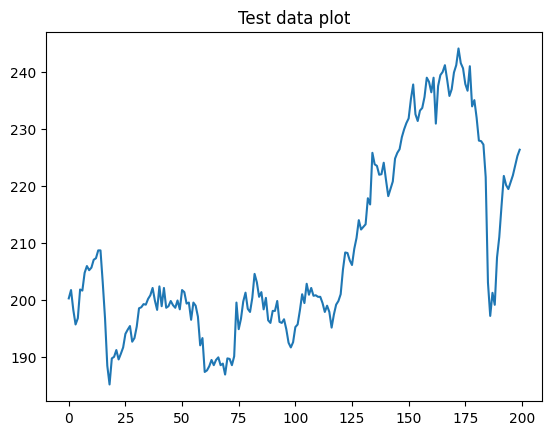

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.7936559930719933
Normalized Benchmark: 0.04147621579227878


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

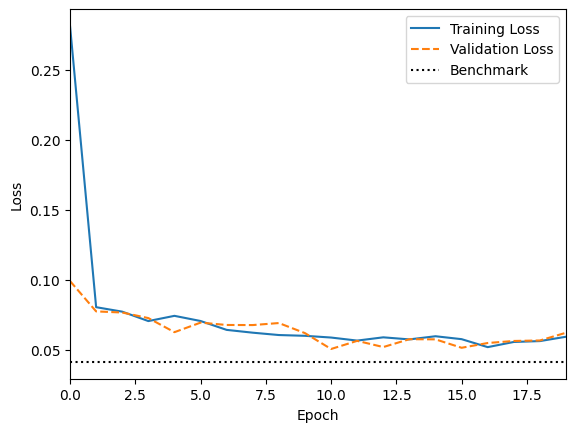

variance of returns for old data:  0.0016938445841587222
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(196.3808)
windows last2 price:  tensor(193.4525)
windows last3 price:  tensor(197.4790)
period from idx:  0  to idx  4
prediction at 4:  tensor(198.8348)
last price from test data:  196.38082885742188
real price 4 steps forward:  tensor(196.7469)
kelly weight:  {tensor(7.3773, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(196.7469)
windows last2 price:  tensor(195.6487)
windows last3 price:  tensor(198.2110)
period from idx:  4  to idx  8
prediction at 4:  tensor(199.4040)
last price from test data:  tensor(196.7469)
real price 4 steps forward:  tensor(205.8979)
kelly weight:  {tensor(7.9732, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(205.8979)
windows last2 price:  tensor(204.7083)
windows last3 pri

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


tensor(210.8394)
windows last3 price:  tensor(208.9177)
period from idx:  128  to idx  132
prediction at 4:  tensor(211.5341)
last price from test data:  tensor(213.9508)
real price 4 steps forward:  tensor(217.7942)
kelly weight:  {tensor(-6.6685, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(217.7942)
windows last2 price:  tensor(213.2187)
windows last3 price:  tensor(212.7612)
period from idx:  132  to idx  136
prediction at 4:  tensor(213.8023)
last price from test data:  tensor(217.7942)
real price 4 steps forward:  tensor(223.4678)
kelly weight:  {tensor(-10.8207, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(223.4678)
windows last2 price:  tensor(223.7424)
windows last3 price:  tensor(225.7556)
period from idx:  136  to idx  140
prediction at 4:  tensor(219.4079)
last price from test data:  tensor(223.4678)
real price 4 steps forward:  tensor(220.9971)
kelly weight:  {tensor(-10.7259, dtype=tor

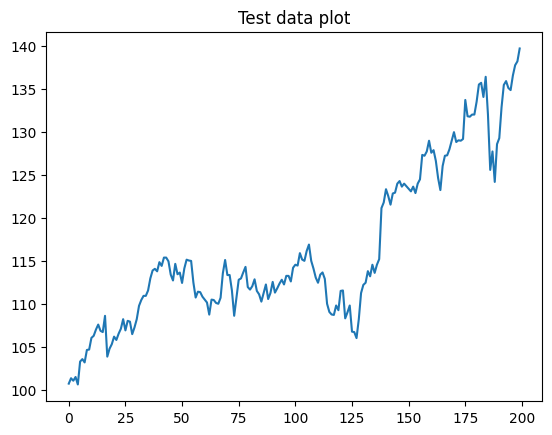

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.3094583912495161
Normalized Benchmark: 0.05767936030121088


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

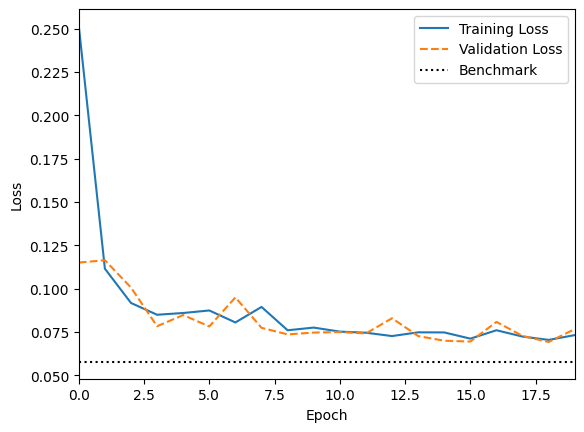

variance of returns for old data:  0.0016779378697753663
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.3526)
windows last2 price:  tensor(99.0436)
windows last3 price:  tensor(98.8497)
period from idx:  0  to idx  4
prediction at 4:  tensor(101.9713)
last price from test data:  100.35257720947266
real price 4 steps forward:  tensor(100.5950)
kelly weight:  {tensor(9.6129, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(100.5950)
windows last2 price:  tensor(101.4676)
windows last3 price:  tensor(101.0313)
period from idx:  4  to idx  8
prediction at 4:  tensor(102.8952)
last price from test data:  tensor(100.5950)
real price 4 steps forward:  tensor(104.6188)
kelly weight:  {tensor(13.6276, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(104.6188)
windows last2 price:  tensor(103.1644)
windows last3 pric

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(123.2500)
windows last2 price:  tensor(124.6500)
windows last3 price:  tensor(126.6500)
period from idx:  164  to idx  168
prediction at 4:  tensor(125.4579)
last price from test data:  tensor(123.2500)
real price 4 steps forward:  tensor(128.)
kelly weight:  {tensor(10.6763, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(128.)
windows last2 price:  tensor(127.3000)
windows last3 price:  tensor(127.2500)
period from idx:  168  to idx  172
prediction at 4:  tensor(128.0034)
last price from test data:  tensor(128.)
real price 4 steps forward:  tensor(129.0500)
kelly weight:  {tensor(0.0156, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(129.0500)
windows last2 price:  tensor(128.8500)
windows last3 price:  tensor(130.)
period from idx:  172  to idx  176
prediction at 4:  tensor(129.8013)
last price from test data:  tensor(129.0500)
real pric

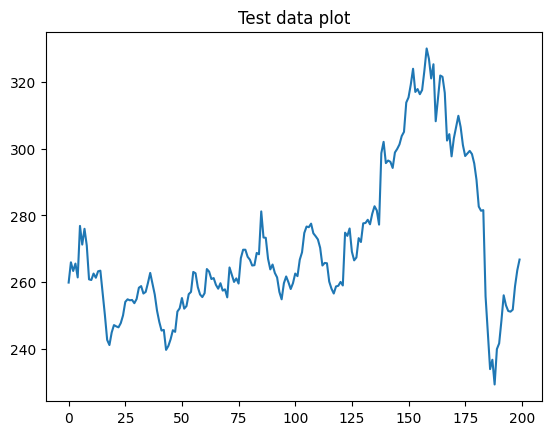

in sequences shape:  (1026, 50, 11)
targets shape:  (1026, 1)
train loader length:  26
val loader length:  7
Benchmark Celsius: 1.9634383230032602
Normalized Benchmark: 0.034243035379359646


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type                 ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ loss          │ L1Loss               │      0 │ eval  │
│ 1 │ train_metrics │ MetricCollection     │      0 │ train │
│ 2 │ val_metrics   │ MetricCollection     │      0 │ train │
│ 3 │ test_metrics  │ MetricCollection     │      0 │ train │
│ 4 │ model         │ CrossAttentionLSTMV1 │  178 K │ train │
│ 5 │ optimizer     │ Adam                 │      0 │ train │
└───┴───────────────┴──────────────────────┴────────┴───────┘

Trainable params: 178 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 178 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 13                                                                                          
Modules in eval mode: 1

Output()

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing 
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data
_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing
the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.

/Users/gabrielmellin/anaconda3/envs/py-torch/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:310: 
The number of training batches (26) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower
value for log_every_n_steps if you want to see logs for the training epoch.

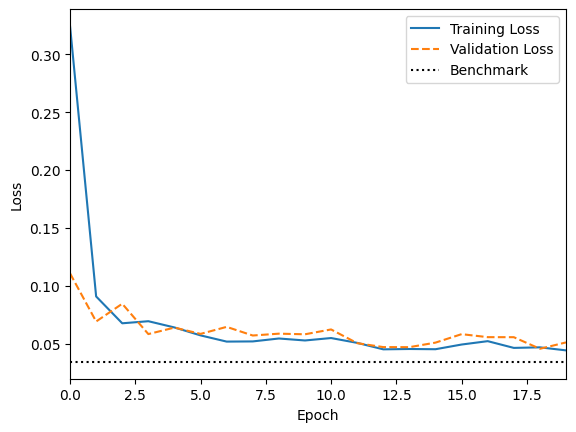

variance of returns for old data:  0.0016452130346617559
start window shape:  torch.Size([50, 11])
test data shape torch.Size([200, 11])
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(256.8238)
windows last2 price:  tensor(253.7389)
windows last3 price:  tensor(256.9202)
period from idx:  0  to idx  4
prediction at 4:  tensor(252.6168)
last price from test data:  256.8238220214844
real price 4 steps forward:  tensor(261.4513)
kelly weight:  {tensor(-9.9567, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(261.4513)
windows last2 price:  tensor(265.5967)
windows last3 price:  tensor(263.3794)
period from idx:  4  to idx  8
prediction at 4:  tensor(256.9004)
last price from test data:  tensor(261.4513)
real price 4 steps forward:  tensor(270.9954)
kelly weight:  {tensor(-10.5800, dtype=torch.float64)}
 
x_in shape:  torch.Size([1, 50, 11])
windows last price:  tensor(270.9954)
windows last2 price:  tensor(276.0085)
windows last3 p

/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:269: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  next_data_point = torch.tensor(true_row, dtype=torch.float32)
/Users/gabrielmellin/Documents/GitHub/Project-AMLNN/model_inference/inference_functions.py:271: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  middle_points = torch.tensor(test_real_data_torch_norm[idx_start+1:idx_end,:], dtype = torch.float32)


In [17]:
from data.data_preprocessing import retrive_and_extract_relevant_data_values, generate_loaders_and_benchmark
from single_asset_models.CrossAttentionGRUV1 import CrossAttentionGRUV1
from single_asset_models.CrossAttentionLSTMV1 import CrossAttentionLSTMV1
from train.train_functions import plot_training
import deeplay as dl

from model_inference.inference_functions import generate_weights_from_predictions
tickers = ['VOLV-B.ST', 'KINV-B.ST', 'TEL2-B.ST', 'SCA-B.ST', 'SWED-A.ST']
all_weights = []
tickers = all_tickers
#tickers = ['TEL2-B.ST']
epochs = 20
for ticker in tickers:
    data_values, dataframe = retrive_and_extract_relevant_data_values(df=df, feature_cols=feature_cols, chosen_ticker=ticker, no_plotting=True)
    n_features = data_values.shape[1]
    train_loader, val_loader, benchmark = generate_loaders_and_benchmark(raw_numpy_data=data_values, 
                                                                     window_step_length=window_step_length,
                                                                     window_size=window_size,
                                                                     num_test_points=num_test_points,
                                                                     horizon=horizon,
                                                                     target_idx=target_idx,
                                                                     minimal_plotting=False
                                                                     )
    cross_attn_lstm_v1 = CrossAttentionLSTMV1(in_dim=n_features, hidden_dim=64, num_hidden_layers=5, out_dim=1, dropout=0.1, num_heads=16)
    #trained_chosen_model_path = train_model(chosen_model, epochs=epochs, optimizer=, train_loader=train_loader, val_loader=val_loader, benchmark=benchmark)
    chosen_model = cross_attn_lstm_v1
    chosen_model_reg = dl.Regressor(chosen_model, optimizer=dl.Adam(lr=0.001)).create()

    trainer = dl.Trainer(max_epochs=epochs, accelerator="auto")
    trainer.fit(chosen_model_reg, train_loader, val_loader)
    train_losses = trainer.history.history["train_loss_epoch"]["value"]
    val_losses = trainer.history.history["val_loss_epoch"]["value"][1:]
    plot_training(epochs, train_losses, val_losses, benchmark)
    preds_norm, weights = generate_weights_from_predictions(chosen_model_reg, 
                                                  window_size, 
                                                  data_values, 
                                                  target_idx,
                                                  num_of_future_predictions=num_test_points, 
                                                  horizon=horizon,
                                                  kelly_clip=15,
                                                  print_values_for_allocation=True)
    all_weights.append(weights)

(22, 200)
(200,)


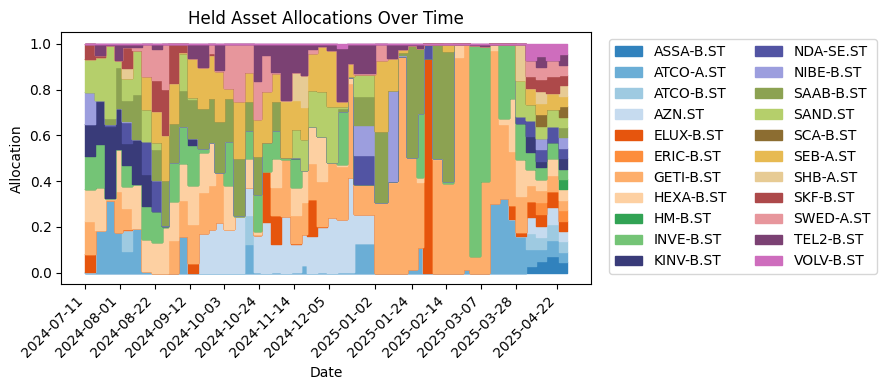

In [18]:
import numpy as np
import matplotlib.pyplot as plt
trading_cost = 0.005

from allocation_functions.allocation_functions import allocate_from_weights, plot_allocations

test_indices = df.index[-num_test_points*22::22]
test_indices = test_indices[:int(horizon*np.floor(num_test_points/horizon))]

alloc = allocate_from_weights(all_weights, horizon=horizon, num_of_test_points=num_test_points)
print(alloc.shape)
alloc_diff = np.diff(alloc, axis=1)
alloc_diff = np.concatenate([alloc_diff, np.zeros((len(tickers),1))], axis=1)
alloc_diff = 0.5* np.sum(np.abs(alloc_diff), axis=0)
print(alloc_diff.shape)

def plot_allocations(alloc, tickers, dates):
    n_assets, total_steps = alloc.shape
    print(total_steps)
    
    

    # Time axis
    t = np.arange(total_steps)

    # Compute cumulative allocations for stacking
    cumsum = np.cumsum(alloc, axis=0)

    plt.figure(figsize=(20,16))
    # Plot filled areas for each asset
    for i in range(n_assets):
        bottom = cumsum[i-1] if i > 0 else np.zeros_like(t)
        top = cumsum[i]
        plt.fill_between(t, bottom, top, step='post', label=tickers[i])
    
    plt.xlabel('Time Step')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend()

    plt.tight_layout()
    plt.show()
#plot_allocations(alloc, tickers, test_indices)

def plot_allocations(alloc, tickers, dates):
    n_assets, T = alloc.shape
    # Stack allocations
    cumsum = np.cumsum(alloc, axis=0)
    base_cmap = plt.get_cmap('tab20c')
    extra_cmap = plt.get_cmap('tab20b')
    colors = []
    for i in range(n_assets):
        if i < 10:
            colors.append(base_cmap(i))  # tab20 has 20 distinct
        else:
            # pick from hsv evenly for any extras
            colors.append(extra_cmap((i-10) / max(1, n_assets-10)))

    #cmap = plt.get_cmap('tab20', n_assets)
    #colors = [cmap(i) for i in range(n_assets)]

    plt.figure(figsize=(9,4))
    for i, ticker in enumerate(tickers):
        bottom = cumsum[i-1] if i>0 else np.zeros(T)
        top    = cumsum[i]
        # use dates on the x-axis
        plt.fill_between(dates, bottom, top, step='post', label=ticker, color=colors[i])

    # now the ticks are the dates themselves
    plt.xticks(
        dates[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )

    plt.xlabel('Date')
    plt.ylabel('Allocation')
    plt.title('Held Asset Allocations Over Time')
    plt.legend(ncol=2, bbox_to_anchor=(1.02,1), loc='upper left')
    plt.tight_layout()
    plt.show()

# call with your alloc, tickers and test_indices as dates:
plot_allocations(alloc, tickers, test_indices)
#np.save('best_allocations.npy',alloc)

200
(22, 200)
(22, 200)
(200,)
Portfoliot final return:  0.797937224435443
Index final return 0.96005725629508


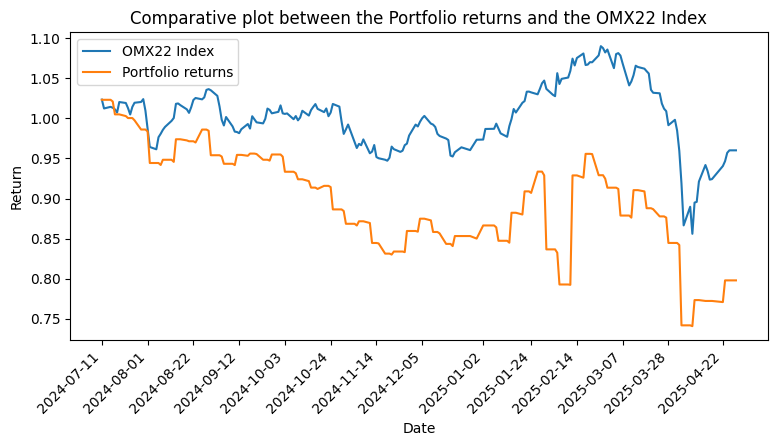

In [19]:
from allocation_functions.allocation_functions import calculate_asset_returns, calculate_portfolio_returns, calculate_cumulative_portfolio_returns, retrieve_test_closing_price
import matplotlib.pyplot as plt


print(len(test_indices))

returns = calculate_asset_returns(df, tickers, horizon, num_of_test_points=num_test_points)
print(alloc.shape)
print(returns.shape)

portfolio_returns = calculate_portfolio_returns(alloc, returns[:,:alloc.shape[1]])
print(portfolio_returns.shape)

portfolio_returns_with_tradingcost = np.where(portfolio_returns > 0, portfolio_returns - alloc_diff*trading_cost, portfolio_returns)
portfolio_returns_with_tradingcost = portfolio_returns - alloc_diff*trading_cost
#print(portfolio_returns_with_tradingcost)
portfolio_cum_return = calculate_cumulative_portfolio_returns(portfolio_returns_with_tradingcost)
print('Portfoliot final return: ',portfolio_cum_return[-1])



df_omx22 = pd.read_csv(
    "data/MCAP_22_Index_raw.csv",
    parse_dates=["Date"],
    index_col="Date"
)


index_test_values = df_omx22['MCAP_22_Index'].iloc[-num_test_points:].values

index_diffs = np.diff(index_test_values, axis=0)
index_diffs = np.concatenate([index_diffs, np.zeros((1))], axis=0)/index_test_values
#print(index_diffs)
cum_prod_index = 1 * np.cumprod(1 + index_diffs)
cum_prod_index = cum_prod_index[:int(horizon*np.floor(num_test_points/horizon))]
print('Index final return', cum_prod_index[-1])
plt.figure(figsize=(9,4))
plt.plot(test_indices, cum_prod_index, label='OMX22 Index')
plt.plot(test_indices, portfolio_cum_return, label='Portfolio returns')
plt.title('Comparative plot between the Portfolio returns and the OMX22 Index')
plt.xlabel('Date')
plt.ylabel('Return')
plt.xticks(
        test_indices[::15], 
        #[d.strftime('%Y-%m-%d') for d in dates],
        rotation=45, ha='right'
    )
plt.legend()



In [20]:
import torch
cross_attn_lstm_v1.eval()

with torch.no_grad():
    for i, batch in enumerate(val_loader):
        x_batch, y_batch = batch
        #print(y_batch)
        test_prediction = cross_attn_lstm_v1(x_batch)
        attn_weights = cross_attn_lstm_v1.get_attn_weights()
        all_attn = attn_weights
        if i > 5:
            break
        
print(all_attn.shape)
attn = all_attn.detach().cpu().numpy()  
#attn = all_attn[0].detach().cpu().numpy() 
 
import random
#random.seed(42)
indices = random.sample(range(21), 4)
print("Randomly selected samples:", indices)

attn4 = attn[indices]

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16,4), sharex=True, sharey=True)

im_mean = attn4.mean(0, keepdims=True)

for i, ax in enumerate(axes):
    im = ax.imshow(
        attn4[i],
        origin="lower",
        cmap="viridis",
        aspect="auto", 
       
    )
    ax.set_title(f"Sample {i}")
    ax.set_xlabel("Key time step")
    if i == 0:
        ax.set_ylabel("Query time step")



plt.tight_layout()
plt.show()

plt.imshow(im_mean)
plt.show()

torch.Size([13, 50, 50])
Randomly selected samples: [6, 12, 18, 7]


IndexError: index 18 is out of bounds for axis 0 with size 13